In [3]:
#%pip install -r requirements-estimation.txt

In [4]:
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip uninstall pandas -y
%pip install pandas --upgrade

Found existing installation: pandas 3.0.2
Uninstalling pandas-3.0.2:
  Successfully uninstalled pandas-3.0.2
Note: you may need to restart the kernel to use updated packages.
  Using cached pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Using cached pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.2.0 requires pandas<3,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
otter-grader 6.1.3 requires wrapt<2.0.0,>=1.16.0, but you have wrapt 2.1.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [6]:
NG_URL= "https://docs.google.com/spreadsheets/d/1rbWPdn_Rt3MRoFb_wkomHBcNVmM-3F3lNwCpxP5W_3g/edit?gid=1354121303#gid=1354121303" 

In [7]:
from eep153_tools.sheets import read_sheets

In [8]:
import pandas as pd
import numpy as np

FE_Sheets = ["Food Expenditures (2010Q3)", "Food Expenditures (2011Q1)", "Food Expenditures (2012Q3)", "Food Expenditures (2013Q1)", "Food Expenditures (2015Q3)", "Food Expenditures (2016Q1)"]

FP_Sheets = ["Food Prices (2010Q3)", "Food Prices (2011Q1)", "Food Prices (2012Q3)", "Food Prices (2013Q1)", "Food Prices (2015Q3)", "Food Prices (2016Q1)"]

def prepare_data(NG_URL, FE_Sheet, household_sheet="Household Characteristics"): 
    x = read_sheets(NG_URL, sheet = FE_Sheet)
    d = read_sheets(NG_URL ,sheet = household_sheet)

    # data cleaning to ensure key columns match exactly
    for df in [x, d]:
        df['i'] = pd.to_numeric(df['i'], errors='coerce')
        df['t'] = df['t'].astype(str).str.strip()
        df['m'] = (
            df['m']
            .astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r'\s+', ' ', regex=True)
        )


    d.columns.name = 'k'
    # remove duplicate column names, keep first occurrence
    d = d.loc[:, ~d.columns.duplicated()]

    # collapse duplicate household rows
    d = d.groupby(['i','t','m'], as_index=False).first()

    # Data comes in long format; pivot to wide (one column per food)
    x = x.pivot_table(index=['i','t','m'],columns='j',values='Expenditure',
                   aggfunc='sum')
    x = x.replace(0,np.nan) # Replace zeros with missing

    # Take logs of expenditures; call this y
    y = x

    d.set_index(['i','t','m'],inplace=True)

    # NaN in demographic columns means zero people in that category
    d = d.fillna(0)

    return y, d

## [B] Nutritional Adequacy of Diet
In this section we look at the proportion of household satisfying the adult nutrition requirement in 2010Q3. 

In [9]:
# Extracting 2010 Q3 from y and d
y, d = prepare_data(NG_URL, "Food Expenditures (2010Q3)")

In [10]:
d_2010Q3 = d.xs('2010Q3', level='t').drop(columns = ['Female NA', 'Male NA'])
d_2010Q3.head()

,k,Female 00-03,Female 04-08,Female 09-13,Female 14-18,Female 19-30,Female 31-50,Female 51+,Male 00-03,Male 04-08,Male 09-13,Male 14-18,Male 19-30,Male 31-50,Male 51+,log HSize
i,m,,,,,,,,,,,,,,,
10001,south east,1,0,0,0,1,2,0,0,0,0,0,1,2,0,1.945910
10002,south east,0,0,0,0,2,1,0,0,0,1,1,1,1,0,1.945910
10003,south east,0,0,1,0,0,1,0,0,1,1,1,0,0,1,1.791759
10004,south east,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0.693147
10005,south east,0,2,0,0,1,1,0,0,0,1,0,0,1,0,1.791759


In [11]:
#Minimum Dietary Nutrition Requirement

RDIs = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vR84qu7yUvdzhiHnPG_7KpVSx9FgiyLrZqJ8Ft3oK-B6xT6i4xN8CNtZ2c9PRGXqxXQCNorzWdF6NnB/pub?gid=0&single=true&output=csv')
bmin = RDIs.set_index('Nutrition')
bmin.head()

,Female 00-03,Female 04-08,Female 09-13,Female 14-18,Female 19-30,Female 31-50,Female 51+,Male 00-03,Male 04-08,Male 09-13,Male 14-18,Male 19-30,Male 31-50,Male 51+
Nutrition,,,,,,,,,,,,,,
Energy,1000.0,1200.0,1600.0,1800.0,2000.0,1800.0,1600.0,1000.0,1400.0,1800.0,2200.0,2400.0,2200.0,2000.0
Protein,13.0,19.0,34.0,46.0,46.0,46.0,46.0,13.0,19.0,34.0,52.0,56.0,56.0,56.0
"Fiber, total dietary",14.0,16.8,22.4,25.2,28.0,25.2,22.4,14.0,19.6,25.2,30.8,33.6,30.8,28.0
"Folate, DFE",150.0,200.0,300.0,400.0,400.0,400.0,400.0,150.0,200.0,300.0,400.0,400.0,400.0,400.0
"Calcium, Ca",700.0,1000.0,1300.0,1300.0,1000.0,1000.0,1200.0,700.0,1000.0,1300.0,1300.0,1000.0,1000.0,1000.0


In [12]:
frames = {}
for nutrient in bmin.index:
    # Multiply the whole household df by the specific row of requirements
    frames[nutrient] = d_2010Q3.multiply(bmin.loc[nutrient], axis=1)
household_rdi = pd.concat(frames, names=['Nutrient']).reorder_levels([1, 2, 0]).sort_index()


In [13]:
household_rdi.head()

k                                             Female 00-03  Female 04-08  \
i     m          Nutrient                                                  
10001 south east Calcium, Ca                         700.0           0.0   
                 Carbohydrate, by difference         130.0           0.0   
                 Energy                             1000.0           0.0   
                 Fiber, total dietary                 14.0           0.0   
                 Folate, DFE                         150.0           0.0   

k                                             Female 09-13  Female 14-18  \
i     m          Nutrient                                                  
10001 south east Calcium, Ca                           0.0           0.0   
                 Carbohydrate, by difference           0.0           0.0   
                 Energy                                0.0           0.0   
                 Fiber, total dietary                  0.0           0.0   
                 Folate, DFE                           0.0           0.0   

k                                             Female 19-30  Female 31-50  \
i     m          Nutrient                                                  
10001 south east Calcium, Ca                        1000.0        2000.0   
                 Carbohydrate, by difference         130.0         260.0   
                 Energy                             2000.0        3600.0   
                 Fiber, total dietary                 28.0          50.4   
                 Folate, DFE                         400.0         800.0   

k                                             Female 51+  Male 00-03  \
i     m          Nutrient                                              
10001 south east Calcium, Ca                         0.0         0.0   
                 Carbohydrate, by difference         0.0         0.0   
                 Energy                              0.0         0.0   
                 Fiber, total dietary                0.0         0.0   
                 Folate, DFE                         0.0         0.0   

k                                             Male 04-08  Male 09-13  \
i     m          Nutrient                                              
10001 south east Calcium, Ca                         0.0         0.0   
                 Carbohydrate, by difference         0.0         0.0   
                 Energy                              0.0         0.0   
                 Fiber, total dietary                0.0         0.0   
                 Folate, DFE                         0.0         0.0   

k                                             Male 14-18  Male 19-30  \
i     m          Nutrient                                              
10001 south east Calcium, Ca                         0.0      1000.0   
                 Carbohydrate, by difference         0.0       130.0   
                 Energy                              0.0      2400.0   
                 Fiber, total dietary                0.0        33.6   
                 Folate, DFE                         0.0       400.0   

k                                             Male 31-50  Male 51+  log HSize  
i     m          Nutrient                                                      
10001 south east Calcium, Ca                      2000.0       0.0        NaN  
                 Carbohydrate, by difference       260.0       0.0        NaN  
                 Energy                           4400.0       0.0        NaN  
                 Fiber, total dietary               61.6       0.0        NaN  
                 Folate, DFE                       800.0       0.0        NaN

In [14]:
wanted_nutrients = household_rdi.index.get_level_values('Nutrient').unique().tolist()
wanted_nutrients

['Calcium, Ca',
 'Carbohydrate, by difference',
 'Energy',
 'Fiber, total dietary',
 'Folate, DFE',
 'Iron, Fe',
 'Magnesium, Mg',
 'Niacin',
 'Phosphorus, P',
 'Potassium, K',
 'Protein',
 'Riboflavin',
 'Thiamin',
 'Vitamin A, RAE',
 'Vitamin B-12',
 'Vitamin B-6',
 'Vitamin C, total ascorbic acid',
 'Vitamin E (alpha-tocopherol)',
 'Vitamin K (phylloquinone)',
 'Zinc, Zn']

In [15]:
food_nutrients = (
    pd.read_csv('FoodNutrientsNG.csv')
    .set_index('Unnamed: 0')
    .rename_axis('Nutrient')
)[wanted_nutrients]

food_nutrients.shape

(41, 20)

# Household Nutrient Intake Model

We aim to compute total nutrient intake for each household and compare it with recommended intake levels.

## Definitions

- $i$: household  
- $j$: nutrient (e.g., protein, calcium)  
- $k \in \mathcal{L}$: food item from the set of foods $\mathcal{L}$  

## Recommended Nutrient Intake

Let $r_i^j$ denote the recommended intake of nutrient $j$ for household $i$. This is computed by aggregating across all household members:

$$
r_i^j = \sum (\text{row}_i^j)
$$

where the summation is taken from the DataFrame `household_rdi`, which provides individual-level recommended daily intake values.

## Converting Expenditure to Quantity

Let:

- $E_i^k$: total expenditure of household $i$ on food $k$  
- $P^k$: price per kg of food $k$  

The quantity of food $k$ consumed, in grams, is:

$$
Q_i^k = \frac{E_i^k}{P^k} \times 1000
$$

## Nutrient Content of Food

Let $N_j^k$ denote the amount of nutrient $j$ in food $k$, measured per 100g from FoodData Central.

## Total Nutrient Intake

The total intake of nutrient $j$ for household $i$, denoted $v_i^j$, is:

$$
v_i^j = \sum_{k \in \mathcal{L}} \left( \frac{E_i^k}{P^k} \times \frac{1000}{100} \times N_j^k \right)
$$

Simplifying:

$$
v_i^j = \sum_{k \in \mathcal{L}} \left( \frac{E_i^k}{P^k} \times 10 \times N_j^k \right)
$$

## Matrix Formulation

Define:

- $Q_i^k = \frac{E_i^k}{P^k} \times 1000$: quantity of food $k$ consumed by household $i$, in grams  
- $A_{kj} = \frac{N_j^k}{100}$: amount of nutrient $j$ per gram of food $k$  

Then:

$$
v_i^j = \sum_k Q_i^k A_{kj}
$$

or in matrix form:

$$
\mathbf{V} = \mathbf{Q}\mathbf{A}
$$

## Nutrient Adequacy

We compare intake to recommended levels using:

$$
\text{Adequacy}_i^j = \frac{v_i^j}{r_i^j}
$$

- If $\text{Adequacy}_i^j > 1$, intake is sufficient.  
- If $\text{Adequacy}_i^j < 1$, intake is deficient.  

## Assumptions

- All purchased food is consumed, with no waste.  
- Prices accurately reflect quantities purchased.  
- Nutrient values are constant across foods and households.  
- Food categories are mapped correctly to nutrient data.

In [48]:
#load price data
prices =read_sheets(NG_URL, sheet = 'Food Prices (2010Q3)')
price_wide = prices.pivot(index=['t', 'm'], columns='j', values='Price')
exp_df = y

# Foods available in all three datasets
matched_foods = (
    exp_df.columns
    .intersection(food_nutrients.index)
    .intersection(price_wide.columns)
)
# Expenditure matrix
E = exp_df[matched_foods]


# Build a dataframe with the household index keys
keys = E.index.to_frame(index=False)[['i', 't', 'm']]



In [52]:
matched_foods

Index(['Bananas', 'Beef', 'Bread', 'Brown beans', 'Cassava (root)',
       'Cassava flour', 'Chicken', 'Chocolate drinks', 'Condiments', 'Eggs',
       'Fish--dried', 'Fish--fresh', 'Fish--frozen', 'Fish--smoked', 'Gari',
       'Goat', 'Groundnut oil', 'Groundnuts',
       'Leaves (Cocoyam, Spinach, etc.)', 'Maize flour', 'Malt drinks',
       'Milk powder', 'Milk tinned (unsweetened)', 'Millet', 'Okra', 'Onions',
       'Other vegetables (fresh or canned)', 'Palm oil', 'Pepper', 'Plantains',
       'Rice--imported', 'Rice--local', 'Sachet water',
       'Soft drinks (Coca Cola, spirit, etc)', 'Sugar', 'Sweet potatoes',
       'Tea', 'Tomato puree (canned)', 'Tomatoes', 'White beans',
       'Yam--roots'],
      dtype='str')

In [58]:
# Price table: (t, m) x food
P = (
    price_wide
    .reset_index()
    .drop(columns='t')     # remove t since constant
    .set_index('m')        # now index is just region
)[matched_foods]

P.index = (
    P.index.astype(str)
    .str.strip()
    .str.lower()
)

In [63]:
m_index = E.index.get_level_values('m')
m_index

P_aligned = P.loc[m_index]
P_aligned.index = E.index
≈ = P_aligned[E.columns]

# Quantity in grams
Q = (E / P_aligned) * 1000

# Nutrient content per gram
A = food_nutrients.loc[matched_foods].fillna(0) / 100

# Total nutrient intake
v = Q.fillna(0) @ A

In [107]:
r = household_rdi.sum(axis=1).unstack('Nutrient')

In [69]:
#divide v by 91.3125 for average daily consumption
v_daily = v/91.3125
v_daily

,,,"Calcium, Ca","Carbohydrate, by difference",Energy,"Fiber, total dietary","Folate, DFE","Iron, Fe","Magnesium, Mg",Niacin,"Phosphorus, P","Potassium, K",Protein,Riboflavin,Thiamin,"Vitamin A, RAE",Vitamin B-12,Vitamin B-6,"Vitamin C, total ascorbic acid",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),"Zinc, Zn"
i,t,m,,,,,,,,,,,,,,,,,,,,
10001,2010Q3,south east,371.730188,263.781219,7736.381767,26.459898,128.670301,15.888749,226.847104,8.995008,756.234429,2913.562484,101.254558,0.379274,0.504251,70.632263,4.341729,1.230450,40.215627,23.883020,33.001016,5.162623
10002,2010Q3,south east,239.659050,362.216904,4305.376481,16.163705,55.313844,10.627122,115.278138,6.235380,449.687258,1675.413387,79.220509,0.316290,0.284838,41.531099,2.783260,0.740430,26.960646,8.732250,14.452807,3.787168
10003,2010Q3,south east,157.416714,1628.943851,8062.939713,13.848083,52.867180,7.648020,110.784771,4.736576,334.833878,1438.696361,35.163474,0.223781,0.235549,50.937958,1.833335,0.652398,18.588320,3.747647,10.801905,1.905274
10004,2010Q3,south east,71.955639,285.647423,2610.938572,4.284413,38.530362,6.409370,93.223858,6.897379,429.698897,1000.229640,48.111855,0.178102,0.183436,33.047999,3.010627,0.684085,7.156809,3.830560,8.895375,4.240984
10005,2010Q3,south east,413.081694,509.946791,4332.443053,22.165746,104.105251,14.414373,182.848985,7.412639,668.438153,2579.447448,84.975662,0.318947,0.410004,163.684480,5.254927,1.255767,48.690296,7.884644,29.699503,3.343653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370036,2010Q3,north central,19.357103,19.343513,1551.211499,3.116570,16.558522,0.760226,17.051335,0.644140,50.967830,564.522930,2.419444,0.024597,0.077678,5.913758,0.087611,0.218371,11.759418,5.497714,4.158248,0.190664
370037,2010Q3,north central,38.210550,61.011092,2194.885821,7.531278,46.202244,1.566984,39.352546,1.286585,108.873804,1405.702007,6.240397,0.091153,0.203255,24.683761,0.100734,0.498834,29.652087,5.843330,6.706553,0.539930
370038,2010Q3,north central,75.184369,56.546226,3705.067762,8.201406,48.350445,2.285438,37.158111,1.214730,104.553046,1405.623545,4.877018,0.073736,0.201002,34.803559,0.152225,0.508255,29.964035,12.850376,10.241752,0.499932


In [76]:
adequacy = v_daily/r

In [77]:
adequacy

,,,"Calcium, Ca","Carbohydrate, by difference",Energy,"Fiber, total dietary","Folate, DFE","Iron, Fe","Magnesium, Mg",Niacin,"Phosphorus, P","Potassium, K",Protein,Riboflavin,Thiamin,"Vitamin A, RAE",Vitamin B-12,Vitamin B-6,"Vitamin C, total ascorbic acid",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),"Zinc, Zn"
i,t,m,,,,,,,,,,,,,,,,,,,,
10001,2010Q3,south east,0.055482,0.289869,0.577342,0.141044,0.050459,0.186926,0.099933,0.093698,0.162282,0.093383,0.317412,0.049256,0.068142,0.013849,0.283773,0.148247,0.078854,0.248781,0.050002,0.086044
10002,2010Q3,south east,0.031534,0.398041,0.298984,0.080177,0.020487,0.119406,0.047833,0.061131,0.074948,0.051236,0.235775,0.039048,0.036518,0.007691,0.171806,0.084140,0.051354,0.086458,0.022407,0.058264
10003,2010Q3,south east,0.022814,2.088390,0.746568,0.091588,0.026434,0.121397,0.062946,0.060725,0.059263,0.053483,0.145907,0.036685,0.039923,0.012424,0.152778,0.094550,0.052361,0.050644,0.023482,0.037358
10004,2010Q3,south east,0.032707,1.098644,0.725261,0.085008,0.048163,0.400586,0.125978,0.229913,0.306928,0.106407,0.471685,0.074209,0.079755,0.020655,0.627214,0.213777,0.043375,0.127685,0.042359,0.223210
10005,2010Q3,south east,0.065569,0.653778,0.424749,0.155222,0.054792,0.200200,0.117967,0.102953,0.153664,0.098452,0.386253,0.056955,0.074546,0.044239,0.460959,0.205863,0.145344,0.112638,0.063190,0.074303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370036,2010Q3,north central,0.007169,0.049599,0.298310,0.042810,0.017430,0.023037,0.021051,0.017893,0.027402,0.045526,0.021039,0.008482,0.027742,0.003113,0.015370,0.070442,0.065330,0.152714,0.017326,0.008667
370037,2010Q3,north central,0.007210,0.093863,0.255219,0.062552,0.030801,0.029018,0.031994,0.022183,0.029828,0.065381,0.035864,0.020256,0.046194,0.008228,0.011193,0.103924,0.114046,0.106242,0.017649,0.014593
370038,2010Q3,north central,0.018796,0.108743,0.500685,0.079164,0.035815,0.051942,0.030457,0.023360,0.033618,0.082200,0.029204,0.017556,0.050251,0.012430,0.018793,0.115512,0.117506,0.251968,0.032513,0.015149


To summarize nutritional outcomes at the regional level, household-level adequacy measures are aggregated by region.

Let $\text{Adequacy}_{i,m}^j$ denote nutrient adequacy for household $i$ in region $m$. Regional average adequacy is computed as

$$
\text{Adequacy}_m^j = \mathbb{E}_i \left[ \text{Adequacy}_{i,m}^j \right].
$$

We also define an inadequacy gap as

$$
\text{Inadequacy}_{i,m}^j = \max(0, 1 - \text{Adequacy}_{i,m}^j),
$$

and report the regional average:

$$
\text{Inadequacy}_m^j = \mathbb{E}_i \left[ \text{Inadequacy}_{i,m}^j \right].
$$

Finally, the share of households below recommended intake is computed as

$$
\Pr(\text{Adequacy}_{i,m}^j < 1).
$$

In [88]:
r_clean = r.replace(0, np.nan)
adequacy = v_daily / r_clean
regional_adequacy = adequacy.groupby(level='m').mean()
regional_adequacy

,"Calcium, Ca","Carbohydrate, by difference",Energy,"Fiber, total dietary","Folate, DFE","Iron, Fe","Magnesium, Mg",Niacin,"Phosphorus, P","Potassium, K",Protein,Riboflavin,Thiamin,"Vitamin A, RAE",Vitamin B-12,Vitamin B-6,"Vitamin C, total ascorbic acid",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),"Zinc, Zn"
m,,,,,,,,,,,,,,,,,,,,
north central,0.016978,0.123925,0.198570,0.069268,0.033071,0.080850,0.040055,0.045703,0.050382,0.045875,0.082253,0.036444,0.044271,0.030259,0.114937,0.087221,0.077177,0.070462,0.015055,0.035940
north east,0.016214,0.100401,0.139036,0.049604,0.028289,0.081433,0.043946,0.048503,0.053343,0.021727,0.089811,0.040283,0.037594,0.027991,0.126394,0.057389,0.031932,0.044835,0.007964,0.041901
north west,0.014869,0.077421,0.094140,0.046738,0.028159,0.085544,0.032730,0.037906,0.037112,0.014647,0.071246,0.032912,0.031988,0.025055,0.077593,0.040097,0.031911,0.032156,0.006616,0.035829
south east,0.044252,0.543281,0.329092,0.121587,0.030803,0.117586,0.046392,0.053710,0.070114,0.060429,0.148543,0.035290,0.040056,0.020724,0.164821,0.077803,0.079131,0.080471,0.022491,0.036727
south south,0.022615,0.173252,0.404779,0.082541,0.034823,0.103681,0.057534,0.061867,0.069433,0.067210,0.108278,0.041024,0.052161,0.029704,0.159568,0.114506,0.111565,0.187462,0.040967,0.046549
south west,0.026220,0.124897,0.230929,0.067737,0.021670,0.100095,0.035597,0.043689,0.052881,0.048188,0.088384,0.024431,0.033588,0.011104,0.099966,0.075553,0.056758,0.088491,0.017546,0.040141


In [90]:
regional_inadequacy = (1 - adequacy).clip(lower=0).groupby(level='m').mean()
regional_inadequacy

,"Calcium, Ca","Carbohydrate, by difference",Energy,"Fiber, total dietary","Folate, DFE","Iron, Fe","Magnesium, Mg",Niacin,"Phosphorus, P","Potassium, K",Protein,Riboflavin,Thiamin,"Vitamin A, RAE",Vitamin B-12,Vitamin B-6,"Vitamin C, total ascorbic acid",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),"Zinc, Zn"
m,,,,,,,,,,,,,,,,,,,,
north central,0.983022,0.877082,0.803852,0.930732,0.966929,0.919485,0.959945,0.954297,0.949618,0.954125,0.917747,0.965338,0.955735,0.971086,0.888241,0.916774,0.925394,0.929538,0.984945,0.964060
north east,0.983786,0.900228,0.871526,0.950396,0.971711,0.919842,0.956054,0.951497,0.946657,0.978273,0.910189,0.959717,0.962406,0.972009,0.874938,0.942611,0.968068,0.957175,0.992036,0.958099
north west,0.985131,0.922579,0.905860,0.953262,0.971841,0.915423,0.967270,0.962094,0.962888,0.985353,0.928754,0.967088,0.968012,0.974945,0.922407,0.959903,0.968089,0.967844,0.993384,0.964171
south east,0.957429,0.668224,0.701616,0.888966,0.969197,0.882414,0.953608,0.946290,0.929886,0.939571,0.852006,0.964710,0.959944,0.979276,0.835825,0.922197,0.920935,0.919529,0.977509,0.963273
south south,0.977385,0.830997,0.745113,0.917459,0.965177,0.897936,0.942466,0.938133,0.930567,0.932790,0.891722,0.958976,0.947839,0.970296,0.841879,0.885580,0.889576,0.872232,0.959033,0.953451
south west,0.979749,0.878830,0.810842,0.932627,0.978330,0.899905,0.964403,0.956311,0.947119,0.953519,0.916870,0.975569,0.966412,0.988896,0.900034,0.924447,0.943242,0.923235,0.982454,0.959859


# Heatmap of regional adequacy

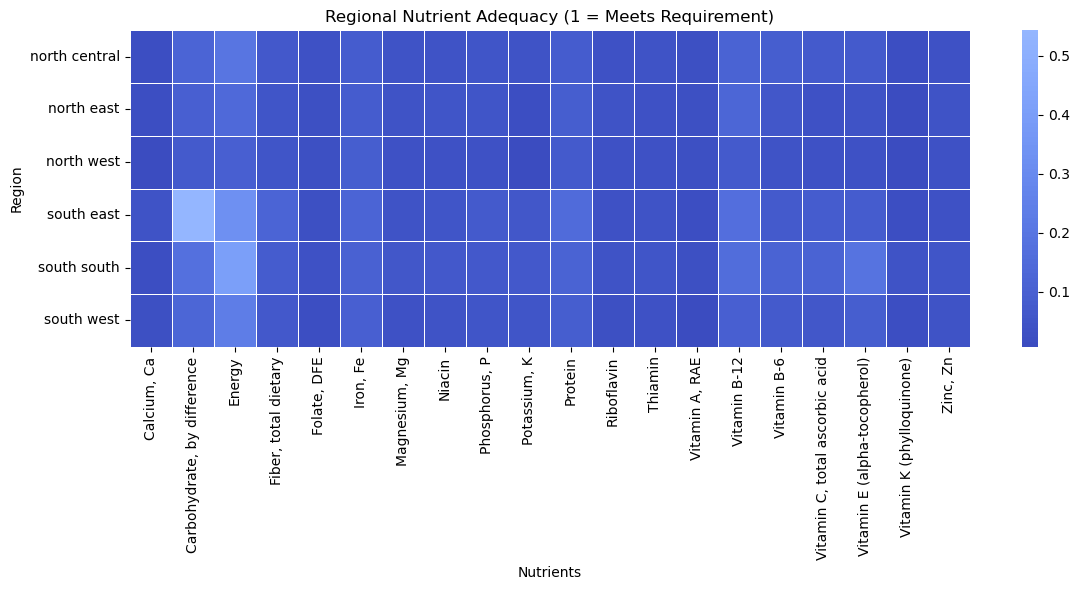

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(
    regional_adequacy,
    cmap='coolwarm',
    center=1,           # 1 = adequate
    annot=False,
    linewidths=0.5
)

plt.title('Regional Nutrient Adequacy (1 = Meets Requirement)')
plt.xlabel('Nutrients')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

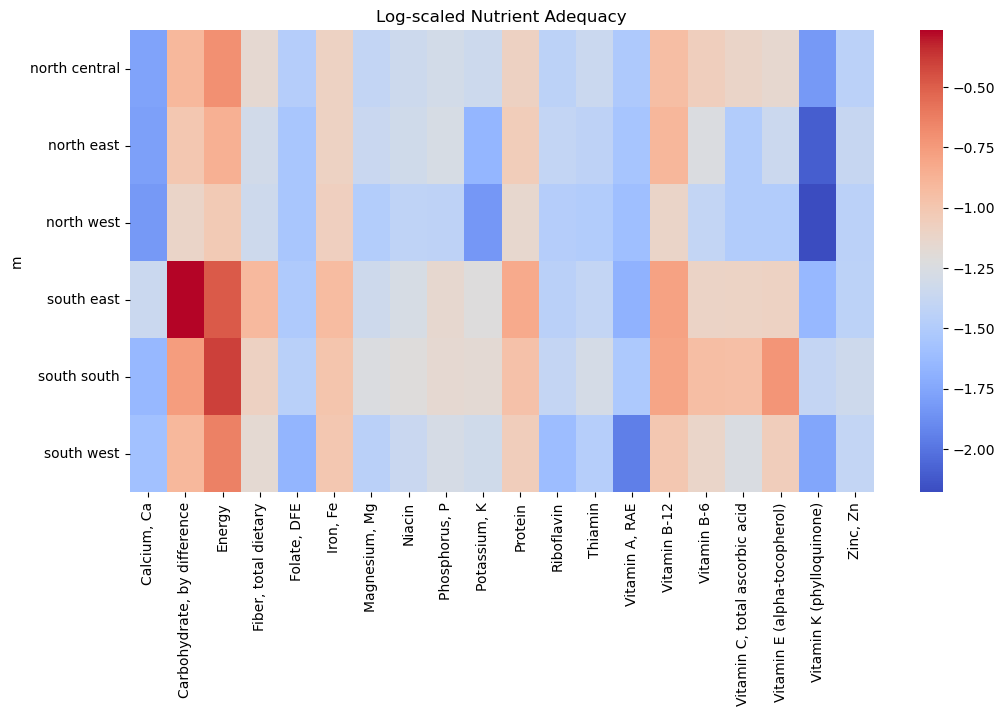

In [105]:
import numpy as np

log_adequacy = np.log10(regional_adequacy)

plt.figure(figsize=(12, 6))

sns.heatmap(
    log_adequacy,
    cmap='coolwarm',   # great for gradients
    annot=False
)

plt.title('Log-scaled Nutrient Adequacy')
plt.show()